# Введение в тематическое моделирование. EM-алгоритм. Регуляризаторы V2

> Лекция составлена по мотивам результатов исследований К. В. Воронцова, доктора физико-математических наук, преподавателя ШАД и МГУ

## Постановка задачи

В NLP мы работаем с коллекциями текстовых документов. Каждый документ представляет собой множество токенов. Говоря о каких-либо документах в реальной жизни мы часто сталкиваемся с таким понятием, как тема. В обработке естественного языка тема, также как и документ, ассоциируется с множеством токенов.

**Замечание:** здесь и далее понятия “токен”, “терм" и “слово” считаем синонимами.

**Тема** - это:

* специальная терминология предметной области;
* набор часто совместно встречающихся токенов;
* кластер текстовых документов.

**Тема - это вероятностное распределение на терминах:** $p(w|t)$ - вероятность встретить термин w в теме t. Это распределение является **латентным**, то есть скрытым.

**Тематический профиль** - это вероятностное распределение на документах: $p(t|d)$ - вероятность темы t для документа d. Это распределение также является **латентным.**

**Замечание:** подобные вероятностные распределения проще всего представлять в виде матриц. Если у нас 500 терминов и 5 тем, то имеет матрицу 500 на 5, сумма чисел в столбце равна единице.

**Тематическое моделирование** - это задача выделения тем и определения тематического профиля каждого документа по **наблюдаемому** распределению $p(w|d)$ (это частота слова в документе). Можно заметить, что тематическое моделирование сильно напоминает задачу кластеризации текстовых документов.

Основное отличие в том, что здесь мы имеем дело с так называемой **мягкой** кластеризацией (документ может принадлежать к **нескольким кластерам**, результат кластеризации задается распределением вероятностей).

**Некоторые приложения тематического моделирования:**

* поиск научной информации;
* агрегирование новостей;
* семантический поиск.

**Пусть:**

* T - множество тем;
* W - множество слов;
* D - множество текстовых документов;
* порядок документов в коллекции не важен;
* порядок слов в документе не важен (структура Bag of Words);
* $D\times{W}\times{T}$ - дискретное вероятностное пространство;
* коллекция документов представляется в виде троек (di, wi, ti); таких троек очевидно   $|D\times{W}\times{T}|$;
* каждое слово w в документе d связано с каждой темой (но с некоторыми - более сильная связь);
* p(w | d, t) = p(w | t) - гипотеза условной независимости (порождение слов в документе не зависит от документа, а зависит от тем, которые затрагиваются в документе).

> Появление слова зависит только от темы, но не от того, в каком документе мы эту тему обсуждаем

> Тема определяется тем, какие слова в ней встречаются чаще

В теме "Космос" высока вероятность слов "ракета", "орбита", "спутник". В теме "Биология"  "клетка", "ДНК" и др.

Идея состоит в том, чтобы **поставить задачу генерации текста (моделирования языка)**:

$$
p(w|d)=\sum_{t\in{T}}p(w|t)p(t|d)
$$

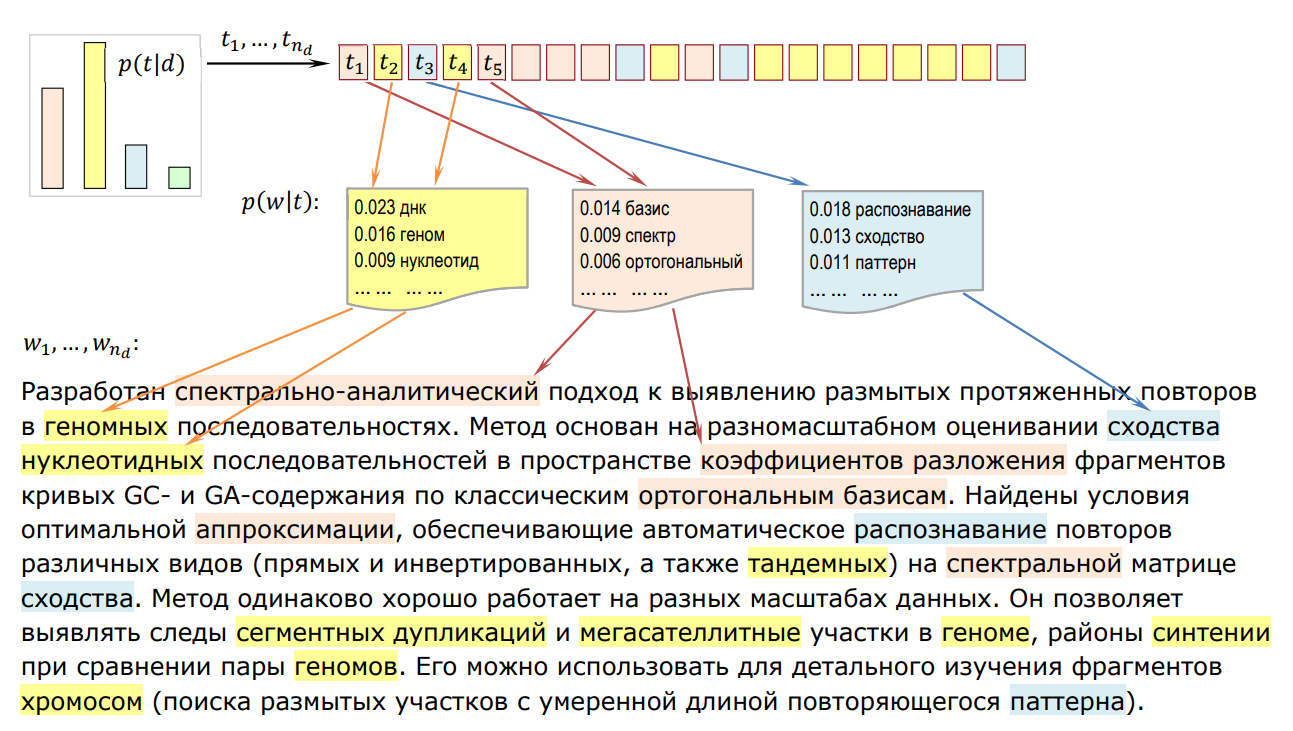

Автор задумал написать статью и решил, в каких пропорциях смешать темы (определил тематический профиль). Автор берет ручку, ставит ее на первое место в предложении и:
- выбирает случайным образом тему из своего профиля
- смотрит в мешок слов этой темы и случайно достает оттуда слово
- записывает слово

> Конечно же, это чисто формальная задача. Никто на самом деле так тексты не генерирует

Куда интереснее решать **обратную задачу**.

Мы знаем $n_{dw}$ - частота термина w в документе d; $n_d$ - количество терминов в документе d; тогда $p(w|d)=\frac{n_{dw}}{n_d}$.

Поскольку мы не знаем вероятности $p(w|t)$ и $p(t|d)$, мы можем рассматривать их как параметры распределения $p(w|d)$. Введем обозначения: $\phi_{wt}=p(w|t)$, $\theta_{td}=p(t|d)$.

Тогда $p(w|d)=\sum_{t\in{T}}\phi_{wt}\theta_{td}$ и имеем задачу стохастического матричного разложения:

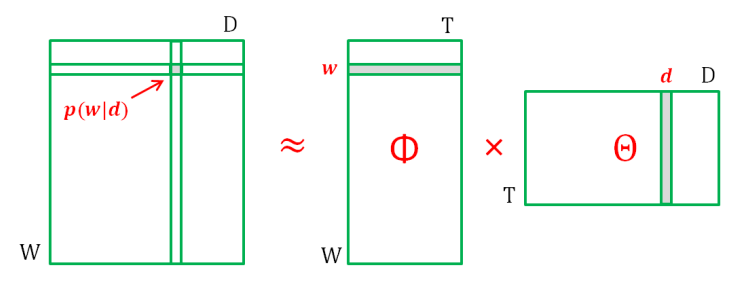

> **Стохастическое** означает, что столбцы всех матриц - векторы, соответствующие дискретным распределениям (нормированы и неотрицательны)

Запишем **правдоподобие** (совместное распределение всей выборки) и поставим задачу его **максимизации**:

$$
\prod_{d\in{D}}\prod_{w\in{d}}p(w|d)^{n_{dw}}\rightarrow{max}
$$

> Правдоподобие - вероятность того, что реальная коллекция текстов могла быть сгенерирована моделью

Произведем классический прием - **логарифмирование**:

$$
\sum_{d\in{D}}\sum_{w\in{d}}n_{dw}ln(p(w|d))\rightarrow{max}
$$

Получаем **задачу математического программирования**:

$$
\sum_{d\in{D}}\sum_{w\in{d}}n_{dw}ln(\sum_{t\in{T}}\phi_{wt}\theta_{td})\rightarrow{max}
$$

При ограничениях в собственном смысле (нормировки):

$$
\sum_{w\in{W}}\phi_{wt}=1, \sum_{t\in{T}}\theta_{td}=1
$$

И ограничениях неотрицательности:

$$
\phi_{wt}\geq0,\theta_{td}\geq0
$$

## EM-алгоритм

Имеем задачу нелинейной условной оптимизации. Чтобы ее решить вспомним, а что вообще называется оптимальным решением **по теореме Каруша-Куна-Таккера**:

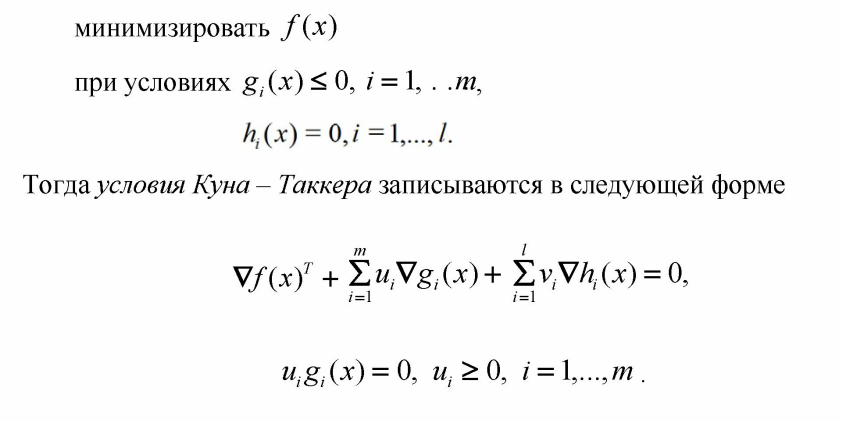

Запишем условия Каруша-Куна-Таккера **для нашей задачи** (поскольку наша целевая функция является функцией двух переменных, условия мы будем расписывать для одной из переменных (**считая другую константой**) - для $\phi_{wt}$; для другой переменной все аналогично):

$$
\sum_{d\in{D}}n_{dw}\frac{\theta_{td}}{p(w|d)}-v_t=0
$$

**Замечание:** знак минус, потому что у нас задача на максимум.

$$
\sum_{d\in{D}}n_{dw}\frac{\theta_{td}}{p(w|d)}=v_t
$$

Умножим обе части уравнения на $\phi_{wt}$:

$$
\sum_{d\in{D}}n_{dw}\frac{\phi_{wt}\theta_{td}}{p(w|d)}=\phi_{wt}v_t=n_{wt}
$$


Здесь имеем:

$$
\frac{\phi_{wt}\theta_{td}}{p(w|d)}=norm_{t\in{T}}(\phi_{wt}\theta_{td})
$$

Но:

$$\sum_{w\in{W}}\phi_{wt}=1$$

Суммируем обе части равенства по словам:

$$
v_t=\sum_{w\in{W}}n_{wt}
$$


Делаем подстановку:

$$
\phi_{wt}\sum_{w\in{W}}n_{wt}=n_{wt}
$$

Отсюда получаем уравнение:

$$
\phi_{wt}=norm_{w\in{W}}n_{wt}
$$

Продолжая рассуждения, мы приходим к уравнениям, по которым можем **итеративно** вычислять $\phi_{wt}$ и $\theta_{td}$:

$$
\phi_{wt}=norm_{w\in{W}}[\sum_{d\in{D}}n_{dw}norm_{t\in{T}}(\phi_{wt}\theta_{td})]
$$

$$
\theta_{td}=norm_{t\in{T}}[\sum_{w\in{d}}n_{dw}norm_{t\in{T}}(\phi_{wt}\theta_{td})]
$$

На практике вычисления организуются в виде **EM-алгоритма**:

**E-шаг:**

$$
p_{tdw}=p(t|d,w)=norm_{t\in{T}}(\phi_{wt}\theta_{td})
$$

**M-шаг:**

$$
\phi_{wt}=norm_{w\in{W}}(\sum_{d\in{D}}n_{dw}p_{tdw})
$$

$$
\theta_{td}=norm_{t\in{T}}(\sum_{w\in{d}}n_{dw}p_{tdw})
$$

**Нормировка:**

$$
norm_{t\in{T}}(x_t)=\frac{max(x_t, 0)}{\sum_{s\in{T}}max(x_s, 0)}
$$

Знаменатель в нашей задаче всегда больше нуля (если коллекция непустая, то $\sum_{d\in{D}}n_{dw}p_{tdw}>0$ и $\sum_{w\in{d}}n_{dw}p_{tdw}>0$). Мы только что получили **алгоритм pLSA** (Probabilistic Latent Semantic Analysis), представленный в 1999 году. Именно с этой идеи началось развитие тематического моделирования.

**Интересный факт:** EM (Expectation–maximization) - алгоритм является своего рода абстракцией над двухшаговыми алгоритмами оптимизации. Вы знаете (и реализовывали в прошлом семестре) как минимум один алгоритм, основанный на этой идее. Какой?

Казалось бы, задача решена, ведь у нас есть конкретные формулы, которые даже можно осознать и использовать? **Но все не так просто!** Задача математического программирования, которую мы сформулировали, является некорректно поставленной по Адамару (решение на самом деле не единственное, их бесконечное множество):

если $\Phi, \Theta$ - решение, то стохастические матрицы $\Phi',\Theta'$ - также решения;

$$
\Phi'\Theta'=(\Phi{S})(S^{-1}\Theta)
$$

Очередная (любая?) квадратная матрица S размера |T| порождает очередное решение. Веселая получается задачка оптимизации конечно 🙂

> Это верно не для любой матрицы $S$, а только для такой, которая сохраняет стохастичность (неотрицательность и нормировку) матриц $\Phi'$ и $\Theta'$

## ARTM и LDA

Для решения этой проблемы **в модель вводят регуляризаторы**, которые позволяют доопределить задачу.

$$
\sum_{d\in{D}}\sum_{w\in{d}}n_{dw}ln(\sum_{t\in{T}}\phi_{wt}\theta_{td})+R(\Phi,\Theta)\rightarrow{max}
$$

$$
R(\Phi,\Theta)=\sum_{i}\tau_{i}R_{i}(\Phi,\Theta)
$$

Рассматриваемый прием называется **аддитивной регуляризацией тематических моделей (ARTM)** и является постановкой задачи оптимизации в общем виде.

**EM-алгоритм в общем виде** выглядит следующим образом (если интересно, попробуйте самостоятельно аналогично вывести его из теоремы Каруша-Куна-Таккера, почти все то же самое):

**E-шаг:**

$$
p_{tdw}=p(t|d,w)=norm_{t\in{T}}(\phi_{wt}\theta_{td})
$$

**M-шаг:**

$$
\phi_{wt}=norm_{w\in{W}}(\sum_{d\in{D}}n_{dw}p_{tdw}+\phi_{wt}\frac{\partial{R}}{\partial{\phi_{wt}}})
$$

$$
\theta_{td}=norm_{t\in{T}}(\sum_{w\in{d}}n_{dw}p_{tdw}+\theta_{td}\frac{\partial{R}}{\partial{\theta_{td}}})
$$

И вот теперь уже есть причина задаться вопросом: как быть, если знаменатель при нормировке будет равен 0 (такое возможно, поскольку частная производная может быть отрицательной, на регуляризаторы не накладывается никаких ограничений).

Действительно, знаменатель может быть равен нулю. Для нас это будет значить, что мы не можем вычислить соответствующие столбцы матриц $\Phi$ и $\Theta$.

Считаем, что **тема t вырождена**, если для всех терминов $w\in{W}$:

$$
\sum_{d\in{D}}n_{dw}p_{tdw}+\phi_{wt}\frac{\partial{R}}{\partial{\phi_{wt}}}\leq0
$$

Если тема вырождена, то $p(w|t)=0$, заполняем столбец нулями. Таким образом **регуляризатор может производить отбор тем.**

Считаем, что **документ d вырожден**, если для всех тем $t\in{T}$:

$$
\sum_{w\in{d}}n_{dw}p_{tdw}+\theta_{td}\frac{\partial{R}}{\partial{\theta_{td}}}\leq0
$$

Если документ вырожден, то $p(t|d)=0$, заполняем столбец нулями. Интерпретируем это так, что **модель не в состоянии описать данный документ**.

Все алгоритмы для решения задачи тематического моделирования могут быть описаны в виде задачи с аддитивной регуляризацией, например LDA, который вы использовали в ЛР 8 по дисциплине “Машинное обучение”.

**LDA (Latent Dirichlet allocation)** на языке регуляризаторов описывается следующим образом:

$$
R(\Phi,\Theta)=\sum_{t,w}(\beta_w-1)ln\phi_{wt}+\sum_{d,t}(\alpha_t-1)ln\theta_{td}
$$

Очевидным образом получаем формулы для M-шага:

$$
\phi_{wt}=norm_{w\in{W}}(\sum_{d\in{D}}n_{dw}p_{tdw}+\beta_w-1)
$$

$$
\theta_{td}=norm_{t\in{T}}(\sum_{w\in{d}}n_{dw}p_{tdw}+\alpha_t-1)
$$

LDA за счет своих гиперпараметров **позволяет управлять разреженностью столбцов матриц** $\Phi, \Theta$**.**

Гипотеза: столбцы $\phi_t$ и $\theta_d$ порождаются [распределением Дирихле](https://habr.com/ru/companies/surfingbird/articles/230103/).

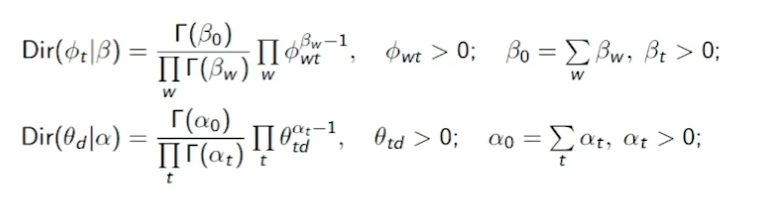

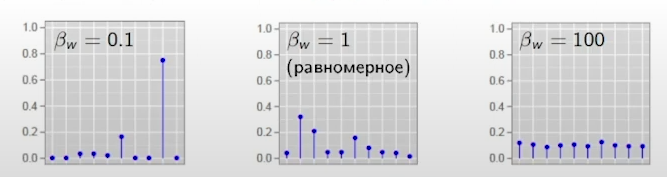

Учитывая, что совместное правдоподобие наблюдаемой выборки и выборки распределения Дирихле определяется следующим образом:

$$
\prod_{d\in{D}}\prod_{w\in{d}}p(w|d)^{n_{dw}}\prod_{t\in{T}}Dir(\phi_t|\beta)\prod_{d\in{D}}Dir(\theta_d|\alpha)\rightarrow{max}
$$

Легко получаем регуляризатор LDA, который был выше (с помощью логарифмирования).

И самое главное, теперь мы понимаем, как с помощью этого регуляризатора создавать вырожденные темы и документы:

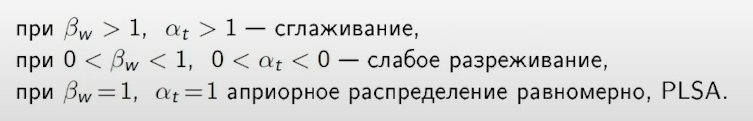

> Специально не убирал опечатку

## Выводы

Задача тематического моделирование - это построение тематических профилей документов и выделение наиболее характерных терминов для каждой темы.

На самом деле мы решаем не задачу моделирования, а обратную задачу, которая в исходной постановке имеет бесконечное множество решений.

Используя идею аддитивной регуляризации мы можем выработать общий подход к решению задачи используя идею EM-алгоритма и придумывать собственные регуляризаторы, а значит и свои алгоритмы тематического моделирования.

Регуляризаторы позволяют производить отбор тем и находить аномалии среди документов.

Наиболее популярный алгоритм LDA основан на идее генерации столбцов искомых матриц с помощью распределения Дирихле, которое задается двумя параметрами. Корректируя значения этих параметров, мы можем получать различные тематические профили и наборы тем.

На следующем занятии мы практически решим задачу тематического моделирования.